# 02 – Data Cleaning

**Purpose:** apply the first cleaning step found necessary in `01_data_audit.ipynb` (removing repeated
environmental uploads), check what usable data remains, and look at the two other things that affect which
project questions are possible: sensor **error codes** and how **irregular** the occupancy events are.

**How to use:** run cells in order with **Shift + Enter** using the `.venv` kernel. Cleaning functions live in
`src/mma3001/cleaning.py` (tested in `tests/test_cleaning.py`); this notebook only applies and inspects them.
Cells marked ✍️ are for your observations and decisions.

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from mma3001.io import load_env, load_occupancy
from mma3001.cleaning import flag_repeated_uploads, remove_repeated_uploads

pd.set_option("display.max_columns", 20)
TZ = "Australia/Melbourne"

---
## Part 1 – Environmental data: removing repeated uploads

### 1.1 Apply the de-duplication
An upload is a **repeat** if an earlier upload from the same sensor contains exactly the same readings
(same variables, same measurement times, same values). See the docstring of `flag_repeated_uploads` for the
full list of assumptions.

In [2]:
env = load_env()

t0 = time.perf_counter()
is_repeat = flag_repeated_uploads(env, match="readings")      # exact copies only (see 1.8)
env_clean = remove_repeated_uploads(env, match="readings")    # readings from non-repeated uploads only
print(f"De-duplication took {time.perf_counter() - t0:.1f} s")

print(f"Uploads:  {len(is_repeat):,} -> {(~is_repeat).sum():,}  ({is_repeat.mean():.1%} were repeats)")
print(f"Readings: {len(env):,} -> {len(env_clean):,}")

De-duplication took 54.3 s
Uploads:  179,447 -> 42,847  (76.1% were repeats)
Readings: 1,939,224 -> 466,237


In [3]:
# Per-sensor summary: how much of each sensor's data survives.
per_sensor = pd.DataFrame({
    "uploads_raw": env.groupby("sensorid")["record_id"].nunique(),
    "uploads_kept": env_clean.groupby("sensorid")["record_id"].nunique(),
    "readings_raw": env.groupby("sensorid").size(),
    "readings_kept": env_clean.groupby("sensorid").size(),
})
per_sensor["percent_kept"] = (100 * per_sensor["uploads_kept"] / per_sensor["uploads_raw"]).round(2)
per_sensor

,uploads_raw,uploads_kept,readings_raw,readings_kept,percent_kept
sensorid,,,,,
6012002000227,21363,2,234993,22,0.01
6012002000241,58908,3,618422,32,0.01
6012002000326,58909,29040,642872,314361,49.30
6012002000777,10926,1,120186,11,0.01
6012002000869,29341,13801,322751,151811,47.04


### 1.2 Before and after: readings per day
Same idea as audit cell B4 (grouped by measurement `time`), raw vs cleaned. Log scale so both the huge
repeat-spikes and normal days are visible; breaks in a line are days with no readings.

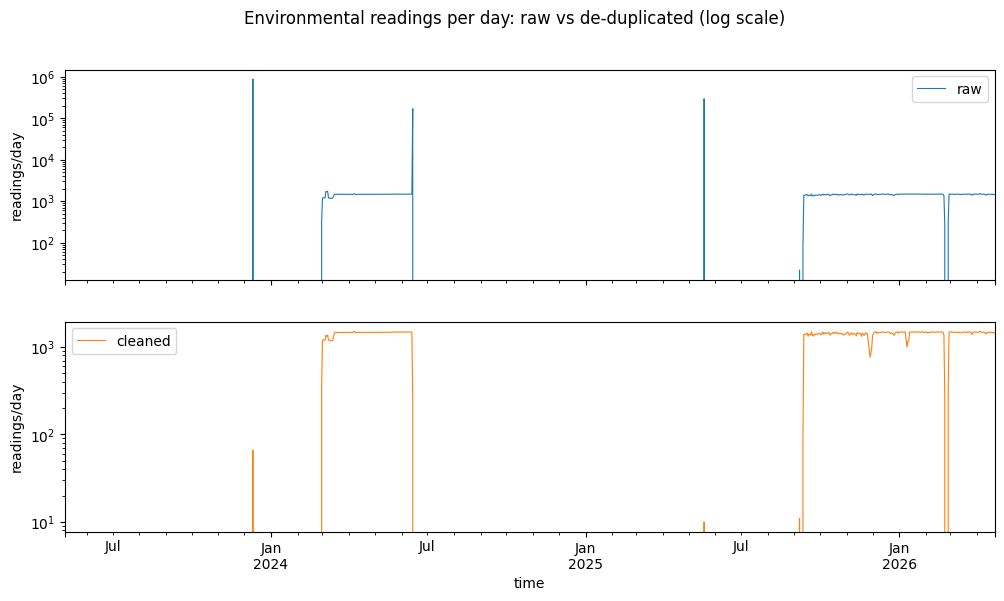

In [4]:
def readings_per_day(df):
    """Count readings per calendar day (Melbourne time) using the measurement time."""
    return df.dropna(subset=["time"]).set_index("time").resample("D").size()

comparison = pd.DataFrame({"raw": readings_per_day(env), "cleaned": readings_per_day(env_clean)}).fillna(0)
axes = comparison.plot(subplots=True, sharex=True, logy=True, figsize=(12, 6), linewidth=0.8,
                       title="Environmental readings per day: raw vs de-duplicated (log scale)")
for ax in axes:
    ax.set_ylabel("readings/day")

### 1.3 Cleaned uploads per day, by sensor
The cleaned version of audit section B5b. Only sensors with a meaningful number of genuine uploads are
plotted (the threshold `MIN_UPLOADS` is a choice – change it to see the others).

Sensors plotted: [6012002000326, 6012002000869]


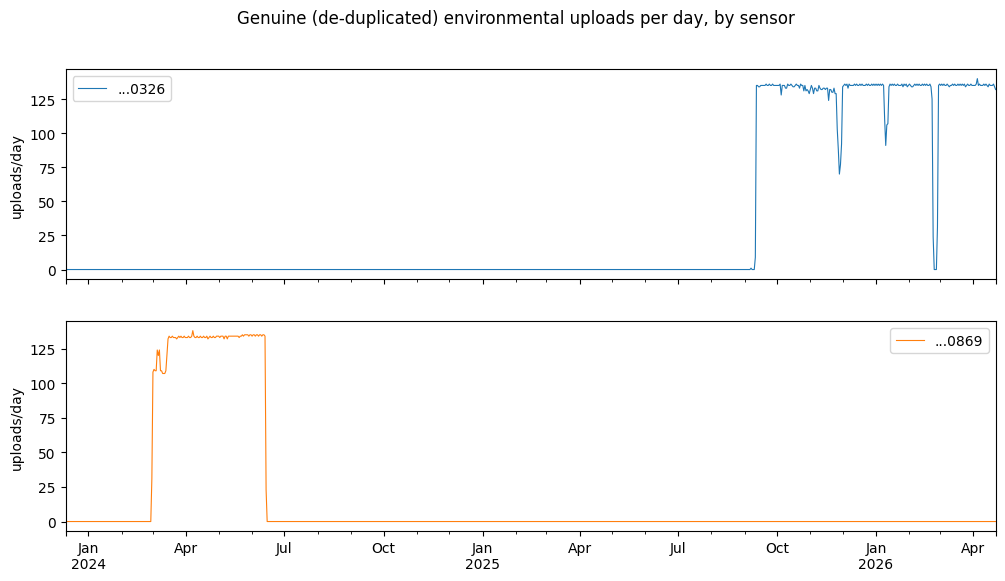

In [5]:
MIN_UPLOADS = 100   # sensors with fewer genuine uploads than this are left out of the plot

clean_uploads = (env_clean.dropna(subset=["time"])
                          .drop_duplicates("record_id")[["record_id", "sensorid", "time"]])
keep = per_sensor.index[per_sensor["uploads_kept"] >= MIN_UPLOADS]
print("Sensors plotted:", list(keep))

daily = (clean_uploads[clean_uploads["sensorid"].isin(keep)]
            .groupby(["sensorid", pd.Grouper(key="time", freq="D")]).size()
            .unstack(level=0).fillna(0))
daily = daily.reindex(pd.date_range(daily.index.min(), daily.index.max(), freq="D"), fill_value=0)
daily.columns = [f"...{str(c)[-4:]}" for c in daily.columns]

axes = daily.plot(subplots=True, sharex=True, figsize=(12, 6), linewidth=0.8,
                  title="Genuine (de-duplicated) environmental uploads per day, by sensor")
for ax in axes:
    ax.set_ylabel("uploads/day")

> ✍️ Two usable sensors do not overlap time periods in which they have genuine readings

### 1.4 How often do the remaining sensors report?
Time between consecutive genuine uploads from the same sensor. A regular interval matters for methods that
assume evenly spaced data (finite differences, numerical integration, many regression set-ups).

In [6]:
clean_uploads = clean_uploads.sort_values(["sensorid", "time"])
interval_min = clean_uploads.groupby("sensorid")["time"].diff().dt.total_seconds() / 60

interval_min.groupby(clean_uploads["sensorid"]).describe(percentiles=[0.5, 0.9, 0.99]).round(1)

,count,mean,std,min,50%,90%,99%,max
sensorid,,,,,,,,
6012002000227,1.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0
6012002000241,2.0,378217.7,534880.5,0.0,378217.7,680791.8,748871.0,756435.3
6012002000326,29039.0,42.8,5376.4,0.0,10.0,10.0,20.0,916148.6
6012002000777,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6012002000869,13800.0,11.0,3.0,0.0,10.0,20.0,20.0,30.0


### 1.5 Continuous usable periods
Split each sensor's data into **segments** wherever there is a gap longer than `GAP_THRESHOLD`, then list the
longest segments. The threshold is a judgement call – try `"30min"`, `"2h"`, `"6h"` and see how the
segments change.

In [7]:
GAP_THRESHOLD = pd.Timedelta("25min")   # a gap longer than this starts a new segment

gaps = clean_uploads.groupby("sensorid")["time"].diff()
# Each time a gap exceeds the threshold, the cumulative sum ticks up -> a new segment number.
segment_no = (gaps > GAP_THRESHOLD).groupby(clean_uploads["sensorid"]).cumsum()

segments = (clean_uploads.groupby([clean_uploads["sensorid"], segment_no.rename("segment")])["time"]
                         .agg(start="min", end="max", uploads="size"))
segments["days"] = ((segments["end"] - segments["start"]).dt.total_seconds() / 86400).round(1)
segments.sort_values("days", ascending=False).head(10)

start                       end  \
sensorid      segment                                                       
6012002000326 2       2025-09-11 22:39:34+10:00 2025-11-18 05:20:35+11:00   
6012002000869 0       2024-02-29 17:04:56+11:00 2024-05-06 16:15:28+10:00   
6012002000326 99      2026-03-10 08:02:04+11:00 2026-04-22 23:12:41+10:00   
              93      2026-01-12 17:51:21+11:00 2026-02-22 20:41:53+11:00   
6012002000869 1       2024-05-06 16:45:27+10:00 2024-06-14 03:45:44+10:00   
6012002000326 55      2025-12-06 20:30:50+11:00 2026-01-09 14:31:17+11:00   
              98      2026-02-27 18:31:56+11:00 2026-03-10 07:22:04+11:00   
              3       2025-11-18 06:40:35+11:00 2025-11-26 10:20:42+11:00   
              54      2025-11-30 17:50:43+11:00 2025-12-06 20:00:50+11:00   
              85      2026-01-11 20:21:20+11:00 2026-01-12 11:21:20+11:00   

                       uploads  days  
sensorid      segment                 
6012002000326 2           9012  67.2  
6012002000869 0           8633  67.0  
6012002000326 99          5909  43.7  
              93          5551  41.1  
6012002000869 1           5168  38.5  
6012002000326 55          4570  33.8  
              98          1428  10.5  
              3           1068   8.2  
              54           821   6.1  
              85            82   0.6

> ✍️ The longest continous period for max gap = 30min is (...0869) witb 105.5 days

### 1.6 One week of real data (corrected version of audit cell B6)
Temperature and CO₂ for the first 7 days of the **longest continuous segment**, using the cleaned data.

Sensor 6012002000326, starting 2025-09-11 22:39:34+10:00


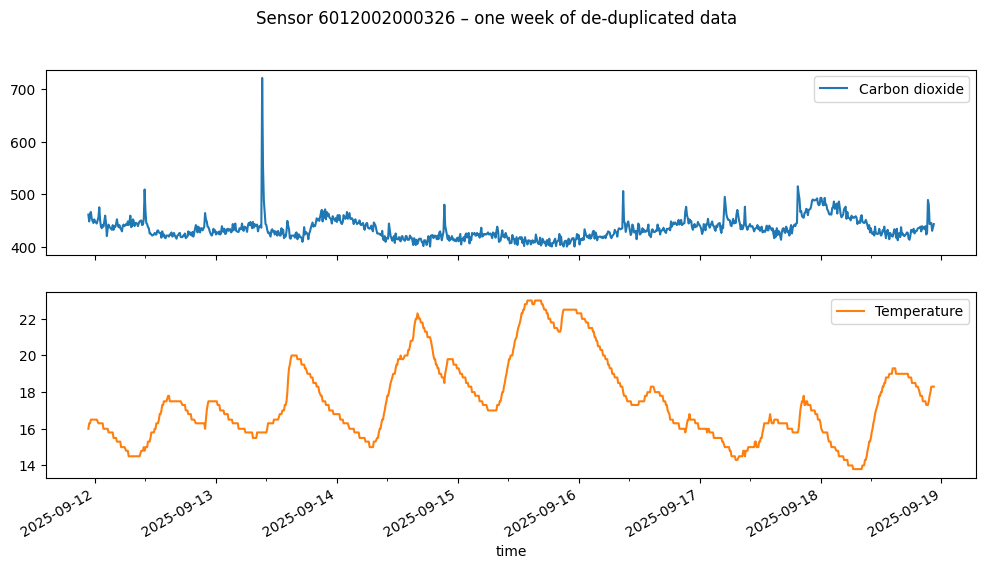

In [8]:
longest = segments.sort_values("days", ascending=False).iloc[0]
sensor, _segment = longest.name
start = longest["start"]
print(f"Sensor {sensor}, starting {start}")

s = env_clean[(env_clean["sensorid"] == sensor)
              & env_clean["variable"].isin(["Temperature", "Carbon dioxide"])
              & (env_clean["time"] >= start)
              & (env_clean["time"] < start + pd.Timedelta(days=7))]
week = s.pivot_table(index="time", columns="variable", values="value", observed=True)
week.plot(subplots=True, figsize=(12, 6), title=f"Sensor {sensor} – one week of de-duplicated data");

> ✍️ The values for temperature do appear to follow seasonality (varying with day and night), which is to be physically expected.

### 1.7 Remaining edge case: "near-repeats"
The de-duplication only removes **exact** copies. A few genuine-looking uploads share a measurement time
with another upload from the same sensor. The table shows how those uploads differ.

In [9]:
same_time = clean_uploads[clean_uploads.duplicated(["sensorid", "time"], keep=False)]
print(f"{len(same_time)} uploads in {same_time.groupby(['sensorid', 'time']).ngroups} groups share a "
      "(sensor, measurement time) with another upload")

ids = same_time["record_id"]
# (groupby + unstack keeps NaN values visible without creating empty filler rows.)
(env_clean[env_clean["record_id"].isin(ids)]
     .groupby(["sensorid", "time", "record_id", "variable"], observed=True)["value"].first()
     .unstack("variable"))

8 uploads in 4 groups share a (sensor, measurement time) with another upload


variable                                           Battery  Carbon dioxide  \
sensorid      time                      record_id                            
6012002000227 2023-12-11 16:07:53+11:00 276298      4.1875           666.0   
                                        536635      4.1875           666.0   
6012002000241 2023-12-11 16:52:45+11:00 2           4.1875           603.0   
                                        536636      4.1875           603.0   
6012002000326 2023-12-11 16:00:57+11:00 5           4.1875           525.0   
                                        536637      4.1875           525.0   
6012002000869 2024-06-14 03:45:44+10:00 474945      4.0312           520.0   
                                        536655      4.0312           520.0   

variable                                           Formaldehyde  Humidity  \
sensorid      time                      record_id                           
6012002000227 2023-12-11 16:07:53+11:00 276298              4.0      69.0   
                                        536635              NaN      69.0   
6012002000241 2023-12-11 16:52:45+11:00 2                   6.0      66.0   
                                        536636              NaN      66.0   
6012002000326 2023-12-11 16:00:57+11:00 5                   5.0      68.0   
                                        536637              NaN      68.0   
6012002000869 2024-06-14 03:45:44+10:00 474945             55.0      42.0   
                                        536655              NaN      42.0   

variable                                           Light Volatile Organic Compounds  \
sensorid      time                      record_id                                     
6012002000227 2023-12-11 16:07:53+11:00 276298                                 15.0   
                                        536635                                 15.0   
6012002000241 2023-12-11 16:52:45+11:00 2                                      14.0   
                                        536636                                 14.0   
6012002000326 2023-12-11 16:00:57+11:00 5                                       7.0   
                                        536637                                  7.0   
6012002000869 2024-06-14 03:45:44+10:00 474945                                  1.0   
                                        536655                                  1.0   

variable                                           Particulate matter 1  \
sensorid      time                      record_id                         
6012002000227 2023-12-11 16:07:53+11:00 276298                      3.0   
                                        536635                      3.0   
6012002000241 2023-12-11 16:52:45+11:00 2                           8.0   
                                        536636                      8.0   
6012002000326 2023-12-11 16:00:57+11:00 5                           6.0   
                                        536637                      6.0   
6012002000869 2024-06-14 03:45:44+10:00 474945                      4.0   
                                        536655                      4.0   

variable                                           Particulate matter 10  \
sensorid      time                      record_id                          
6012002000227 2023-12-11 16:07:53+11:00 276298                       3.0   
                                        536635                       3.0   
6012002000241 2023-12-11 16:52:45+11:00 2                            9.0   
                                        536636                       9.0   
6012002000326 2023-12-11 16:00:57+11:00 5                            6.0   
                                        536637                       6.0   
6012002000869 2024-06-14 03:45:44+10:00 474945                       7.0   
                                        536655                       7.0   

variable                                           Particulate ma

> ✍️ These should all be removed as well, the NaN will only complicate analysis and it doesn't make much physical sense for a single sensor to have mulitple readings at a single timestamp.

### 1.8 Applying the stricter rule: one upload per sensor per measurement time
Sections 1.1–1.7 removed **exact** copies only (`match="readings"`). Every upload contains a single
measurement time, and a sensor cannot take two different sets of readings at the same instant, so the
project's cleaning rule is stricter: keep **one upload per sensor per measurement time** – the one that
arrived first (`match="time"`, the default in `cleaning.py`). This also removes the near-repeats from 1.7.

**From here on, `env_clean` uses this stricter rule** (Parts 2 onwards). Sections 1.2–1.6 above used the
exact-copies version; the difference is only the uploads listed below.

In [10]:
env_exact = env_clean                                   # 1.1 result: exact copies removed
env_clean = remove_repeated_uploads(env, match="time")  # stricter rule (the default)

removed_ids = sorted(set(env_exact["record_id"]) - set(env_clean["record_id"]))
print(f"Uploads kept: exact-copies rule {env_exact['record_id'].nunique():,} -> "
      f"stricter rule {env_clean['record_id'].nunique():,} ({len(removed_ids)} more removed)")
print(f"Readings kept: {len(env_exact):,} -> {len(env_clean):,}")

# Check: no sensor now has two uploads with the same measurement time.
uploads_now = env_clean.dropna(subset=["time"]).drop_duplicates("record_id")
print("Sensor/time pairs still with more than one upload:",
      uploads_now.duplicated(["sensorid", "time"]).sum())

# The removed near-repeat uploads, one column per variable.
# (groupby + unstack keeps NaN values visible without creating empty filler rows.)
(env_exact[env_exact["record_id"].isin(removed_ids)]
     .groupby(["sensorid", "time", "record_id", "variable"], observed=True)["value"].first()
     .unstack("variable"))

Uploads kept: exact-copies rule 42,847 -> stricter rule 42,843 (4 more removed)
Readings kept: 466,237 -> 466,193
Sensor/time pairs still with more than one upload: 0


,,variable,Battery,Carbon dioxide,Formaldehyde,Humidity,Light Volatile Organic Compounds,Particulate matter 1,Particulate matter 10,Particulate matter 2.5,Particulate matter 4,Pressure,Temperature
sensorid,time,record_id,,,,,,,,,,,
6012002000227,2023-12-11 16:07:53+11:00,536635,4.1875,666.0,NaN,69.0,15.0,3.0,3.0,3.0,3.0,1011.0,24.0
6012002000241,2023-12-11 16:52:45+11:00,536636,4.1875,603.0,NaN,66.0,14.0,8.0,9.0,9.0,9.0,1011.0,23.8
6012002000326,2023-12-11 16:00:57+11:00,536637,4.1875,525.0,NaN,68.0,7.0,6.0,6.0,6.0,6.0,1012.0,23.8
6012002000869,2024-06-14 03:45:44+10:00,536655,4.0312,520.0,NaN,42.0,1.0,4.0,7.0,6.0,7.0,1016.0,21.5


---
## Part 2 – Sensor error codes decision
Some readings carry an `errorCode` from the sensor, with or without a value. This section only *describes*
them; no rule is applied yet.

In [11]:
flagged = env_clean[env_clean["error_code"].notna()]
print(f"{len(flagged):,} of {len(env_clean):,} cleaned readings have an error code\n")

# Which variables, which codes, and whether a value was still reported.
pd.crosstab(flagged["variable"], [flagged["error_code"], flagged["value"].notna().rename("has value")])

7,010 of 466,193 cleaned readings have an error code



error_code,4.0,8.0
has value,False,True
variable,,
Formaldehyde,2411,4599


In [12]:
# Percentage of each variable's readings that carry an error code.
(env_clean.assign(has_error=env_clean["error_code"].notna())
          .groupby("variable", observed=True)["has_error"].mean()
          .mul(100).round(2).sort_values(ascending=False))

variable
Formaldehyde                        16.36
Battery                              0.00
Carbon dioxide                       0.00
Humidity                             0.00
Light Volatile Organic Compounds     0.00
Particulate matter 1                 0.00
Particulate matter 10                0.00
Particulate matter 2.5               0.00
Particulate matter 4                 0.00
Pressure                             0.00
Temperature                          0.00
Name: has_error, dtype: float64

> ✍️  Due to the issues in sensor readings of Formaldehyde already discussed, I will leave these errors as I believe the data too unreliable to use anyway.
>
> 

---
## Part 3 – Occupancy: how regular are the events?
Occupancy rows are **events** (a row is written when something changes), not measurements at fixed times.
Most numerical methods need **evenly spaced** data, so an occupancy analysis will need a step that converts
events into a regular time series.

### 3.1 Time between events

In [13]:
t0 = time.perf_counter()
occ = load_occupancy()
print(f"Loaded {len(occ):,} rows in {time.perf_counter() - t0:.1f} s")

o = occ[["floorspaceid", "collecteddate", "headcount"]].sort_values(["floorspaceid", "collecteddate"])
gap_s = o.groupby("floorspaceid", observed=True)["collecteddate"].diff().dt.total_seconds()

print("Seconds between consecutive events in the same space:")
gap_s.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).round(1)

Loaded 9,091,732 rows in 147.2 s
Seconds between consecutive events in the same space:


count    9091727.0
mean          33.9
std          884.4
min            0.0
10%            2.0
25%            2.0
50%            4.0
75%           14.0
90%           34.0
99%          284.0
max      1349782.0
Name: collecteddate, dtype: float64

Gaps longer than 1 hour: 9,123   longer than 1 day: 31


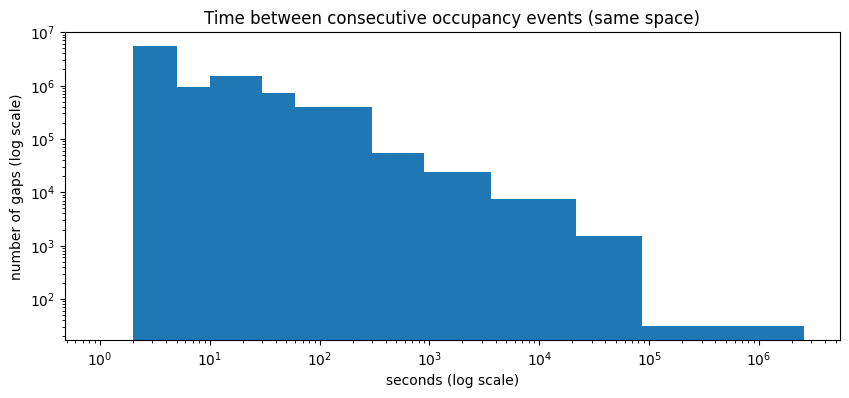

In [14]:
# Histogram on a log x-axis: gaps range from 1 second to many days.
bins = [1, 2, 5, 10, 30, 60, 300, 900, 3600, 6 * 3600, 86400, 30 * 86400]
ax = gap_s[gap_s > 0].plot(kind="hist", bins=bins, logx=True, logy=True, figsize=(10, 4),
                           title="Time between consecutive occupancy events (same space)")
ax.set_xlabel("seconds (log scale)"); ax.set_ylabel("number of gaps (log scale)");

print(f"Gaps longer than 1 hour: {(gap_s > 3600).sum():,}   longer than 1 day: {(gap_s > 86400).sum():,}")

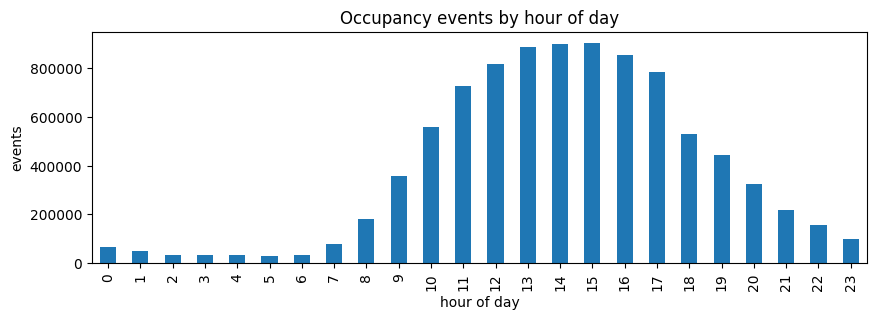

In [15]:
# When during the day do events happen? (All spaces, whole period.)
ax = o["collecteddate"].dt.hour.value_counts().sort_index().plot(kind="bar", figsize=(10, 3),
                                                                  title="Occupancy events by hour of day")
ax.set_xlabel("hour of day"); ax.set_ylabel("events");

### 3.2 Converting events to a regular time series – an example
For one space on one day: the head count as reported by events (step plot), and the same thing sampled every
`STEP` by taking the **last reported head count** in each interval and carrying it forward through intervals
with no events. This is one possible conversion, not the only one – e.g. taking the *maximum* or *mean* head
count in each interval would give different answers.

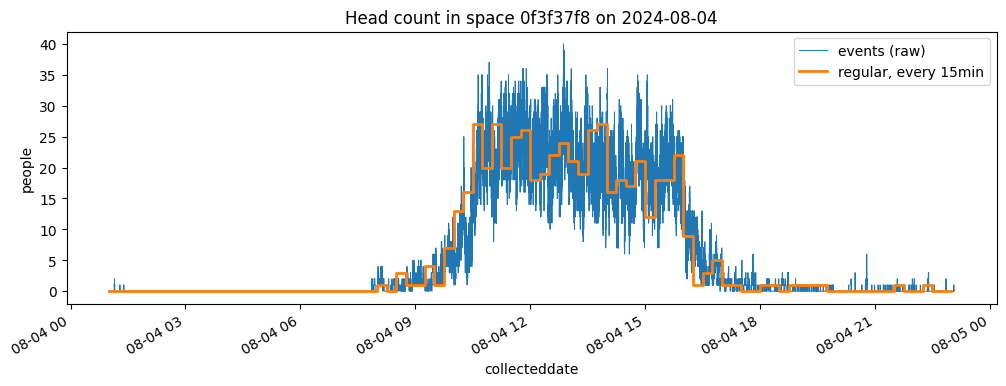

In [16]:
STEP = "15min"

space = o["floorspaceid"].value_counts().index[0]               # busiest space
one_space = o[o["floorspaceid"] == space].set_index("collecteddate")["headcount"]
day = one_space.index.normalize().value_counts().index[0]        # its busiest day
one_day = one_space[day : day + pd.Timedelta(days=1)]

regular = one_day.resample(STEP).last().ffill()                  # last value in each step, carried forward

ax = one_day.plot(drawstyle="steps-post", figsize=(12, 4), linewidth=0.7, label="events (raw)")
regular.plot(ax=ax, drawstyle="steps-post", linewidth=2, label=f"regular, every {STEP}")
ax.set_title(f"Head count in space {str(space)[:8]} on {day.date()}"); ax.set_ylabel("people"); ax.legend();

> ✍️ This is obviously not going to be a perfect solution. Step size choice would also affect accuracy and physical plausability (overfitting vs underfitting).

---
## Summary – what is usable?

> ✍️ After cleaning, much of the takeaway remains the same in terms of what projects are physically plausible. The date ranges for data essentially remains the same and is one of the key attributes of the data that drives what we are able to do with it. One of the other big factors for which a decision will have to be made, is whether to convert the irregular occupancy readings to a regular time series. 